# Tarea 1: Regresión Lineal - Caso Aplicado

MDS7104: Aprendizaje de Maquinas - Otoño 2026

---

### Cuerpo Docente:

- Profesor: Francisco Vásquez L.
- Auxiliares: Álvaro Márquez y Diego Olguín Wende
- Ayudantes: Javiera Yañez y Tamara Carrasco


### Estudiante

- Felipe Muñoz M.

#a) Implementar la clase LinearRegression

Para implementar la clase LinearRegression que calcula una regresión lineal a una función, se utilizaran dos métodos:
* fit(): Esta funcipon estima el parámetro theta_mc mediante mínimos cuadrados. Es decir, mediante la siguiente expresión:
\begin{equation*}
\hat{\theta}_{MC} = (X^{T} \cdot X)^{-1}\cdot X^{T}\cdot y
\end{equation*}

* predict(): Realiza una predicción usando $\hat{\theta}_{MC}$ estimado en fit.

In [1]:
!uv add numpy requests pandas matplotlib scipy scikit-learn ruff pre-commit

Resolved 63 packages in 18ms
Audited 58 packages in 9ms


In [2]:
!uv add ipykernel ipython matplotlib-inline

Resolved 63 packages in 4ms
Audited 58 packages in 1ms


In [3]:
import os

os.environ.pop("MPLBACKEND", None)

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt

In [23]:
import json

import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.preprocessing import StandardScaler

In [12]:
%matplotlib inline

In [5]:
class LinearRegression:
    def __init__(self):
        self.theta = None

    def fit(self, X, y):
        """
        Estima el parámetro theta_MC mediante Mínimos Cuadrados.
        Solución de forma cerrada: theta = (X^T X)^{-1} X^T y
        """
        XtX = X.T @ X
        Xty = X.T @ y
        self.theta = np.linalg.inv(XtX) @ Xty

    def predict(self, X):
        """
        Realiza una predicción usando theta_MC estimado en fit.
        """
        if self.theta is None:
            raise ValueError("El modelo no ha sido entrenado. usar fit() primero.")
        return X @ self.theta

#b) Distribución de las calificaciones en el conjunto de datos

Se procede a importar la base de datos desde mi repositorio en Github

In [ ]:
# Clonar el repo completo con LFS
#!git lfs install
#!git clone https://github.com/FeLiJaNdRo/MDS7104-ML.git

In [ ]:
# Cargar el archivo en Google Colab
# with open('/Users/felijandro/Documents/Universidad/12voSemestre/AprendizajedeMaquinas/MDS7104-ML/tareas/tarea1/Musical_Instruments.jsonl', 'r') as f:
#    data = [json.loads(line) for line in f]
# df = pd.DataFrame(data)



In [6]:
with open("/Users/felijandro/Documents/Universidad/12voSemestre/AprendizajedeMaquinas/MDS7104-ML/tareas/tarea1/Musical_Instruments.jsonl.json") as f:
    data = [json.loads(line) for line in f]
df = pd.DataFrame(data)

In [7]:
print(df.columns.tolist())
print(df.dtypes)
print(df.head(3))

['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object
   rating                              title  \
0     5.0                Love these speakers   
1     4.0                   Good Quick Shine   
2     5.0  Tamborine - good value for price.   

                                                text images        asin  \
0             Love these speakers... loud and clear!     []  B076ZZ131M   
1  I don't know that it is a whole lot better tha...     []  B000A6ASQ0   
2  Sturdy and Easy to hold, grandbaby is 4yrs old...     []  B092DHKPHV   

  parent_asin                       user_id      timestamp  helpful_vote  \
0  B

Se procede a crear la columna lenght_of_review usando el número de palabras

In [8]:
df["length_of_review"] = df["text"].fillna("").apply(lambda x: len(x.split()))

Se calculan métricas de interés como promedio y varianza.

In [9]:
promedio = df["rating"].mean()
varianza = df["rating"].var()


print(f"Promedio : {promedio:.4f}")
print(f"Varianza : {varianza:.4f}")

Promedio : 4.2484
Varianza : 1.6515


Se crea el histograma para observar la distribución de las calificaciones en el conjunto de datos.

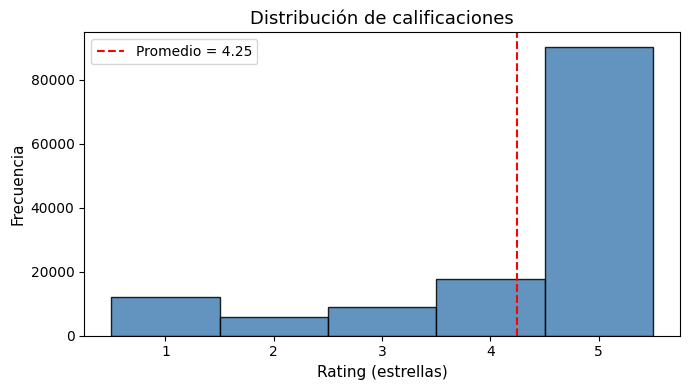

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(df["rating"], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], edgecolor="black", color="steelblue", alpha=0.85)


ax.axvline(promedio, color="red", linestyle="--", linewidth=1.5, label=f"Promedio = {promedio:.2f}")

ax.set_xlabel("Rating (estrellas)", fontsize=11)
ax.set_ylabel("Frecuencia", fontsize=11)
ax.set_title("Distribución de calificaciones", fontsize=13)
ax.set_xticks([1, 2, 3, 4, 5])
ax.legend()
plt.tight_layout()
plt.savefig("histograma_ratings.png", dpi=150)
plt.show()

#c) Entrenamiento y evaluación del modelo

1. Preprocesamiento: Se realiza un preprocesamiento de los datos, donde se puede observar que la columna 'verified_purcharse' es del tipo bool, pero se convertira a tipo binario, es decir, solo toma valores 1 y 0.


In [15]:
# Preprocesamiento

# Convertir verified_purchase a binario
df["verified_purchase"] = df["verified_purchase"].astype(int)

2. Definir X e y: Se seleccionan los atributos que se usaran para la regresión, las cuales corresponden a las columnas 'verified_purchase', 'helpful_vote', 'length_of_review'.  

In [16]:
# Definir X e y

# Agregar columna de unos para el término independiente θ0
X = df[["verified_purchase", "helpful_vote", "length_of_review"]].values
X = np.hstack([np.ones((X.shape[0], 1)), X])  # columna de 1s para θ0

y = df["rating"].values

3. Partición 80/20: El 80% de los datos se usaran para entrenamiento, mientras que el 20% se usará para testeo. Para ello, se particionan de forma aleatoria, usando el rut como semilla.

In [17]:
# Partición

RUT = 20857818  # para Semilla aleatoria

np.random.seed(RUT)
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

4. Entrenar el modelo: El modelo se entrena usando la clase LinearRegression anteriormente creada.  

In [18]:
# Entrenar el modelo

model = LinearRegression()
model.fit(X_train, y_train)

theta = model.theta
print(f"θ0 (intercepto)        : {theta[0]:.4f}")
print(f"θ1 (verified_purchase) : {theta[1]:.4f}")
print(f"θ2 (helpful_vote)      : {theta[2]:.4f}")
print(f"θ3 (length_of_review)  : {theta[3]:.4f}")

θ0 (intercepto)        : 4.1838
θ1 (verified_purchase) : 0.1317
θ2 (helpful_vote)      : 0.0002
θ3 (length_of_review)  : -0.0012


5. Métricas: Se caclucan métricas como RMSE, ECM, MAE y R2 para evaluar la robustes del modelo.

In [19]:
# Métricas


def metricas(y_true, y_pred):
    len(y_true)
    ecm = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(ecm)
    mae = np.mean(np.abs(y_true - y_pred))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return ecm, rmse, mae, r2


y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

ecm_tr, rmse_tr, mae_tr, r2_tr = metricas(y_train, y_pred_train)
ecm_te, rmse_te, mae_te, r2_te = metricas(y_test, y_pred_test)

ecm_mco_train = ecm_tr
ecm_mco_test = ecm_te


print(f"\n{'Métrica':<8} {'Entrenamiento':>15} {'Prueba':>10}")
print("-" * 36)
print(f"{'ECM':<8} {ecm_tr:>15.4f} {ecm_te:>10.4f}")
print(f"{'RMSE':<8} {rmse_tr:>15.4f} {rmse_te:>10.4f}")
print(f"{'MAE':<8} {mae_tr:>15.4f} {mae_te:>10.4f}")
print(f"{'R2':<8} {r2_tr:>15.4f} {r2_te:>10.4f}")


Métrica    Entrenamiento     Prueba
------------------------------------
ECM               1.6347     1.6613
RMSE              1.2786     1.2889
MAE               0.9947     1.0017
R2                0.0065     0.0085


# d)  LASSO y Ridge Regression

1. Valores de lambda a explorar: Se usarán distintos valores para el hiperparámetro de regularización λ.

In [20]:
# 1. Valores de lambda a explorar
lambdas = np.logspace(-4, 3, 1000)  # de 0.0001 a 1000

In [21]:
# Partición

RUT = 20857818  # para Semilla aleatoria

np.random.seed(RUT)
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

2. Almacenar métricas y normas: Se almacenan metricas del método lasso y Ridge

In [24]:
# Almacenar métricas y normas
ecm_train_lasso, ecm_test_lasso = [], []
ecm_train_ridge, ecm_test_ridge = [], []
norm_lasso, norm_ridge = [], []
thetas_lasso, thetas_ridge = [], []

for lam in lambdas:
    # LASSO
    lasso = Lasso(alpha=lam)
    lasso.fit(X_train, y_train)
    ecm_train_lasso.append(np.mean((y_train - lasso.predict(X_train)) ** 2))
    ecm_test_lasso.append(np.mean((y_test - lasso.predict(X_test)) ** 2))
    norm_lasso.append(np.linalg.norm(lasso.coef_, ord=1))
    thetas_lasso.append(lasso.coef_)

    # Ridge
    ridge = Ridge(alpha=lam)
    ridge.fit(X_train, y_train)
    ecm_train_ridge.append(np.mean((y_train - ridge.predict(X_train)) ** 2))
    ecm_test_ridge.append(np.mean((y_test - ridge.predict(X_test)) ** 2))
    norm_ridge.append(np.linalg.norm(ridge.coef_, ord=2))
    thetas_ridge.append(ridge.coef_)

3. Gráfico ECM vs Lambda: Se gráfica el ECM en función de éste para ambos datasets.

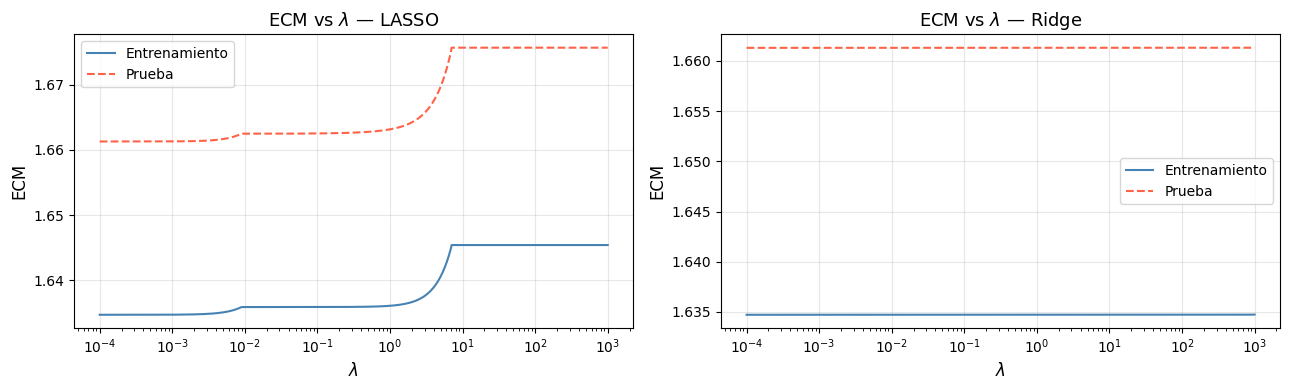

In [25]:
# 3. Gráfico ECM vs Lambda
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, ecm_tr, ecm_te, titulo in zip(axes, [ecm_train_lasso, ecm_train_ridge], [ecm_test_lasso, ecm_test_ridge], ["LASSO", "Ridge"], strict=False):
    ax.plot(lambdas, ecm_tr, label="Entrenamiento", color="steelblue")
    ax.plot(lambdas, ecm_te, label="Prueba", color="tomato", linestyle="--")
    ax.set_xscale("log")
    ax.set_xlabel("$\\lambda$", fontsize=12)
    ax.set_ylabel("ECM", fontsize=12)
    ax.set_title(f"ECM vs $\\lambda$ — {titulo}", fontsize=13)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ecm_lambda.png", dpi=150)
plt.show()

4. Gráfico norma de parámetros vs Lambda: Se Grafica la norma de los parámetros encontrados para los distintos modelos

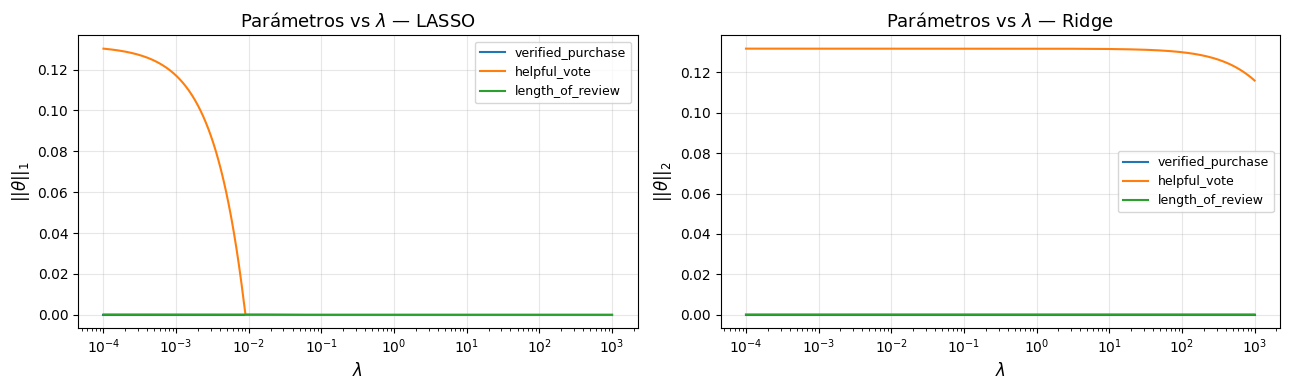

In [26]:
# 4. Gráfico norma de parámetros vs Lambda
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

feature_names = ["verified_purchase", "helpful_vote", "length_of_review"]

for ax, thetas, _norma, titulo, ylabel in zip(
    axes,
    [thetas_lasso, thetas_ridge],
    [norm_lasso, norm_ridge],
    ["LASSO", "Ridge"],
    ["$||\\theta||_1$", "$||\\theta||_2$"],
    strict=False,
):
    thetas = np.array(thetas)
    for i, name in enumerate(feature_names):
        ax.plot(lambdas, thetas[:, i], label=name)
    ax.set_xscale("log")
    ax.set_xlabel("$\\lambda$", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"Parámetros vs $\\lambda$ — {titulo}", fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("norma_parametros.png", dpi=150)
plt.show()

5. Tabla comparativa con lambda óptimo: Se comparan las metricas de ECM en Train y Test entre los tres modelos, donde para LASSO y Ridge se elige aquellos modelos cuyo lambda sea óptimo, es decir el menor ECM para test.

In [27]:
# Tabla comparativa con lambda óptimo (menor ECM test)
print(f"\n{'Modelo':<10} {'ECM Train':>12} {'ECM Test':>12}")
print("-" * 36)
print(f"{'MCO':<10} {ecm_mco_train:>12.4f} {ecm_mco_test:>12.4f}")
print(f"{'LASSO*':<10} {np.mean(ecm_train_lasso):>12.4f} {np.mean(ecm_test_lasso):>12.4f}")
print(f"{'Ridge*':<10} {np.mean(ecm_train_ridge):>12.4f} {np.mean(ecm_test_ridge):>12.4f}")


Modelo        ECM Train     ECM Test
------------------------------------
MCO              1.6347       1.6613
LASSO*           1.6388       1.6668
Ridge*           1.6347       1.6613


# e) Matriz de Correlaciones

In [28]:
# Matriz de correlaciones
features = df[["verified_purchase", "helpful_vote", "length_of_review"]].copy()
features["verified_purchase"] = features["verified_purchase"].astype(float)
corr_matrix = features.corr()
print(corr_matrix)

                   verified_purchase  helpful_vote  length_of_review
verified_purchase           1.000000     -0.019364         -0.236427
helpful_vote               -0.019364      1.000000          0.189438
length_of_review           -0.236427      0.189438          1.000000


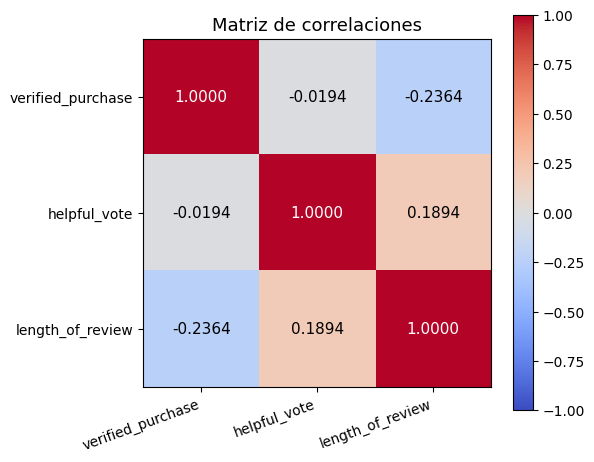

In [29]:
# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

# Etiquetas
feature_names = ["verified_purchase", "helpful_vote", "length_of_review"]
ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=20, ha="right", fontsize=10)
ax.set_yticklabels(feature_names, fontsize=10)

# Valores dentro de cada celda
for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.4f}",
            ha="center",
            va="center",
            fontsize=11,
            color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black",
        )

ax.set_title("Matriz de correlaciones", fontsize=13)
plt.tight_layout()
plt.savefig("correlaciones.png", dpi=150)
plt.show()

# f) Resultados usando escalado a los datos

Primero, se escalan los datos usando StandardScaler de la libreria sklearn.preprocessing, donde se realiza solo con los datos del train, pues esto es así para no introducir data leakage, es decir, el escalado debe reflejar únicamente la distribución del conjunto de entrenamiento.

In [30]:
# Escalar X (solo con estadísticas del train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[:, 1:])  # excluir columna de 1s
X_test_scaled = scaler.transform(X_test[:, 1:])

# Re-agregar columna de unos para θ0
X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_test_scaled = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])

Luego, se aplica MCO usando los datos escalados

In [31]:
# MCO con datos escalados
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

theta_scaled = model_scaled.theta
print("Parámetros MCO escalado:")
print(f"θ0 (intercepto)        : {theta_scaled[0]:.4f}")
print(f"θ1 (verified_purchase) : {theta_scaled[1]:.4f}")
print(f"θ2 (helpful_vote)      : {theta_scaled[2]:.4f}")
print(f"θ3 (length_of_review)  : {theta_scaled[3]:.4f}")

# Métricas MCO escalado
y_pred_train_sc = model_scaled.predict(X_train_scaled)
y_pred_test_sc = model_scaled.predict(X_test_scaled)
ecm_tr_sc, rmse_tr_sc, mae_tr_sc, r2_tr_sc = metricas(y_train, y_pred_train_sc)
ecm_te_sc, rmse_te_sc, mae_te_sc, r2_te_sc = metricas(y_test, y_pred_test_sc)

print(f"\n{'Métrica':<8} {'Train (escalado)':>18} {'Test (escalado)':>16}")
print("-" * 44)
print(f"{'ECM':<8} {ecm_tr_sc:>18.4f} {ecm_te_sc:>16.4f}")
print(f"{'RMSE':<8} {rmse_tr_sc:>18.4f} {rmse_te_sc:>16.4f}")
print(f"{'MAE':<8} {mae_tr_sc:>18.4f} {mae_te_sc:>16.4f}")
print(f"{'R2':<8} {r2_tr_sc:>18.4f} {r2_te_sc:>16.4f}")

Parámetros MCO escalado:
θ0 (intercepto)        : 4.2509
θ1 (verified_purchase) : 0.0354
θ2 (helpful_vote)      : 0.0020
θ3 (length_of_review)  : -0.0894

Métrica    Train (escalado)  Test (escalado)
--------------------------------------------
ECM                  1.6347           1.6613
RMSE                 1.2786           1.2889
MAE                  0.9947           1.0017
R2                   0.0065           0.0085


Luego, se aplica LASSO y Ridge con datos escalados

In [32]:
# LASSO y Ridge con datos escalados
ecm_train_lasso_sc, ecm_test_lasso_sc = [], []
ecm_train_ridge_sc, ecm_test_ridge_sc = [], []
thetas_lasso_sc, thetas_ridge_sc = [], []

for lam in lambdas:
    # LASSO
    lasso_sc = Lasso(alpha=lam)
    lasso_sc.fit(X_train_scaled, y_train)
    ecm_train_lasso_sc.append(np.mean((y_train - lasso_sc.predict(X_train_scaled)) ** 2))
    ecm_test_lasso_sc.append(np.mean((y_test - lasso_sc.predict(X_test_scaled)) ** 2))
    thetas_lasso_sc.append(lasso_sc.coef_)

    # Ridge
    ridge_sc = Ridge(alpha=lam)
    ridge_sc.fit(X_train_scaled, y_train)
    ecm_train_ridge_sc.append(np.mean((y_train - ridge_sc.predict(X_train_scaled)) ** 2))
    ecm_test_ridge_sc.append(np.mean((y_test - ridge_sc.predict(X_test_scaled)) ** 2))
    thetas_ridge_sc.append(ridge_sc.coef_)

Se realiza el Gráfico ECM vs Lambda

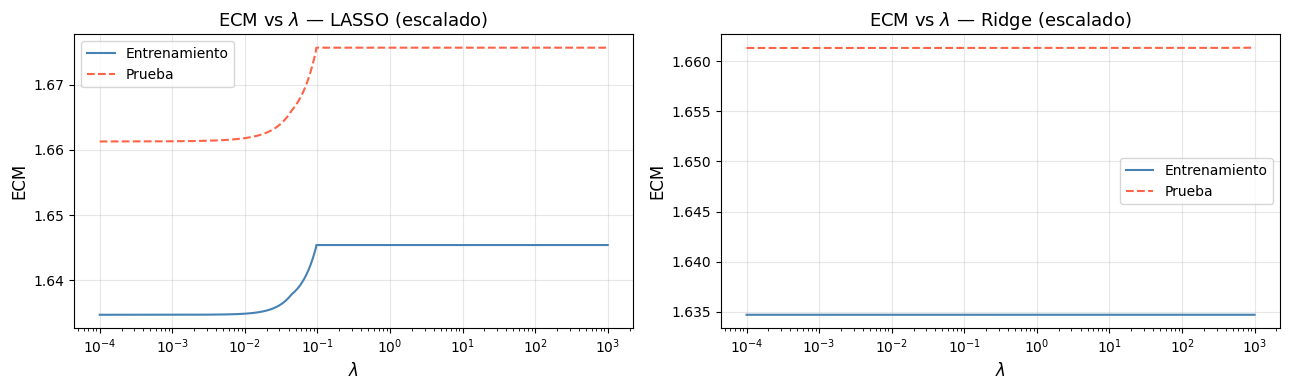

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, ecm_train, ecm_test, titulo in zip(
    axes,
    [ecm_train_lasso_sc, ecm_train_ridge_sc],
    [ecm_test_lasso_sc, ecm_test_ridge_sc],
    ["LASSO (escalado)", "Ridge (escalado)"],
    strict=False,
):
    ax.plot(lambdas, ecm_train, label="Entrenamiento", color="steelblue")
    ax.plot(lambdas, ecm_test, label="Prueba", color="tomato", linestyle="--")
    ax.set_xscale("log")
    ax.set_xlabel("$\\lambda$", fontsize=12)
    ax.set_ylabel("ECM", fontsize=12)
    ax.set_title(f"ECM vs $\\lambda$ — {titulo}", fontsize=13)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ecm_lambda_scaled.png", dpi=150)
plt.show()

Se realiza el Gráfico parámetros vs Lambda

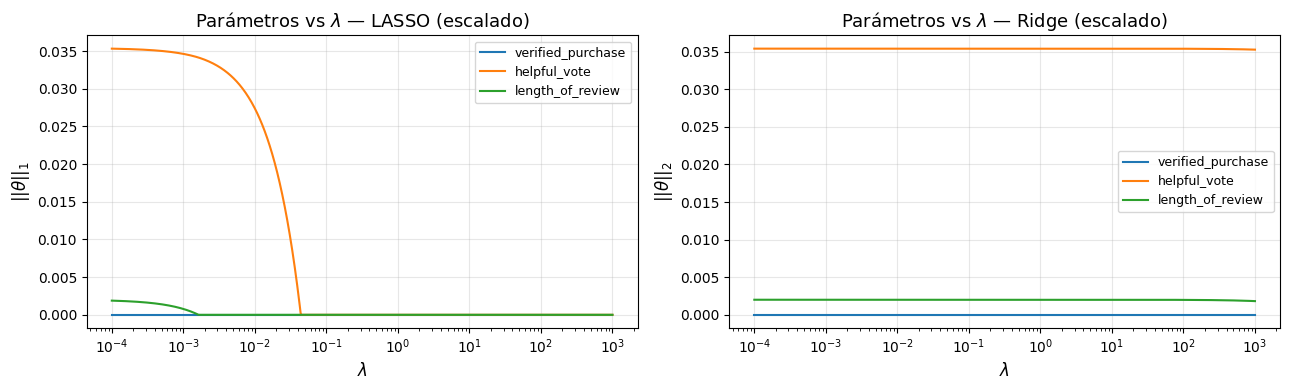

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
feature_names = ["verified_purchase", "helpful_vote", "length_of_review"]

for ax, thetas, titulo, ylabel in zip(
    axes,
    [thetas_lasso_sc, thetas_ridge_sc],
    ["LASSO (escalado)", "Ridge (escalado)"],
    ["$||\\theta||_1$", "$||\\theta||_2$"],
    strict=False,
):
    thetas_arr = np.array(thetas)
    for i, name in enumerate(feature_names):
        ax.plot(lambdas, thetas_arr[:, i], label=name)
    ax.set_xscale("log")
    ax.set_xlabel("$\\lambda$", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"Parámetros vs $\\lambda$ — {titulo}", fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("norma_parametros_scaled.png", dpi=150)
plt.show()

Finalmente, se imprime la tabla comparativa final

In [35]:
print(f"\n{'Modelo':<20} {'ECM Train':>12} {'ECM Test':>12}")
print("-" * 46)
print(f"{'MCO (sin escalar)':<20} {ecm_mco_train:>12.4f} {ecm_mco_test:>12.4f}")
print(f"{'MCO (escalado)':<20} {ecm_tr_sc:>12.4f} {ecm_te_sc:>12.4f}")
print(f"{'LASSO (escalado)*':<20} {np.mean(ecm_train_lasso_sc):>12.4f} {np.mean(ecm_test_lasso_sc):>12.4f}")
print(f"{'Ridge (escalado)*':<20} {np.mean(ecm_train_ridge_sc):>12.4f} {np.mean(ecm_test_ridge_sc):>12.4f}")


Modelo                  ECM Train     ECM Test
----------------------------------------------
MCO (sin escalar)          1.6347       1.6613
MCO (escalado)             1.6347       1.6613
LASSO (escalado)*          1.6412       1.6702
Ridge (escalado)*          1.6347       1.6613


In [36]:
# Métricas MCO escalado
y_pred_train_sc = model_scaled.predict(X_train_scaled)
y_pred_test_sc = model_scaled.predict(X_test_scaled)
ecm_tr_sc, rmse_tr_sc, mae_tr_sc, r2_tr_sc = metricas(y_train, y_pred_train_sc)
ecm_te_sc, rmse_te_sc, mae_te_sc, r2_te_sc = metricas(y_test, y_pred_test_sc)


# Métricas promedio para LASSO, Ridge escalado
def metricas_promedio(ecm_train_list, ecm_test_list, thetas_list, X_train, X_test, y_train, y_test, model_class, lambdas, **kwargs):
    rmse_tr_list, mae_tr_list, r2_tr_list = [], [], []
    rmse_te_list, mae_te_list, r2_te_list = [], [], []

    for lam in lambdas:
        m = model_class(alpha=lam, **kwargs)
        m.fit(X_train, y_train)
        _, rmse_tr, mae_tr, r2_tr = metricas(y_train, m.predict(X_train))
        _, rmse_te, mae_te, r2_te = metricas(y_test, m.predict(X_test))
        rmse_tr_list.append(rmse_tr)
        mae_tr_list.append(mae_tr)
        r2_tr_list.append(r2_tr)
        rmse_te_list.append(rmse_te)
        mae_te_list.append(mae_te)
        r2_te_list.append(r2_te)

    return {
        "ECM Tr": np.mean(ecm_train_list),
        "ECM Te": np.mean(ecm_test_list),
        "RMSE Tr": np.mean(rmse_tr_list),
        "RMSE Te": np.mean(rmse_te_list),
        "MAE Tr": np.mean(mae_tr_list),
        "MAE Te": np.mean(mae_te_list),
        "R2 Tr": np.mean(r2_tr_list),
        "R2 Te": np.mean(r2_te_list),
    }


res_lasso = metricas_promedio(
    ecm_train_lasso_sc,
    ecm_test_lasso_sc,
    thetas_lasso_sc,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    Lasso,
    lambdas,
)

res_ridge = metricas_promedio(
    ecm_train_lasso_sc,
    ecm_test_lasso_sc,
    thetas_lasso_sc,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    Ridge,
    lambdas,
)

# Tabla comparativa
header = f"{'Modelo (Escalado)':<12} {'ECM Tr':>8} {'ECM Te':>8} {'RMSE Tr':>9} {'RMSE Te':>9} {'MAE Tr':>8} {'MAE Te':>8} {'R2 Tr':>7} {'R2 Te':>7}"
print(header)
print("-" * len(header))

# MCO
print(f"{'MCO':<12} {ecm_tr_sc:>8.4f} {ecm_te_sc:>8.4f} {rmse_tr_sc:>9.4f} {rmse_te_sc:>9.4f} {mae_tr_sc:>8.4f} {mae_te_sc:>8.4f} {r2_tr_sc:>7.4f} {r2_te_sc:>7.4f}")

# Regularizados
for nombre, res in [("LASSO*", res_lasso), ("Ridge*", res_ridge)]:
    print(f"{nombre:<12} {res['ECM Tr']:>8.4f} {res['ECM Te']:>8.4f} {res['RMSE Tr']:>9.4f} {res['RMSE Te']:>9.4f} {res['MAE Tr']:>8.4f} {res['MAE Te']:>8.4f} {res['R2 Tr']:>7.4f} {res['R2 Te']:>7.4f}")

Modelo (Escalado)   ECM Tr   ECM Te   RMSE Tr   RMSE Te   MAE Tr   MAE Te   R2 Tr   R2 Te
-----------------------------------------------------------------------------------------
MCO            1.6347   1.6613    1.2786    1.2889   0.9947   1.0017  0.0065  0.0085
LASSO*         1.6412   1.6702    1.2811    1.2923   1.0002   1.0082  0.0025  0.0032
Ridge*         1.6412   1.6702    1.2786    1.2889   0.9947   1.0017  0.0065  0.0085


# g) Agregar variables al modelo

Se extraen el mes y año del timestamp

In [37]:
# Extraer mes y año
df["date"] = pd.to_datetime(df["timestamp"], unit="ms")  # El timestamp está en milisegundos
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year

print("Rango de fechas:")
print(f"Desde : {df['date'].min()}")
print(f"Hasta : {df['date'].max()}")
print(df[["date", "month", "year"]].head())

Rango de fechas:
Desde : 2001-03-15 21:34:41
Hasta : 2023-09-06 14:09:25.498000
                     date  month  year
0 2021-06-06 01:53:09.946      6  2021
1 2013-08-16 02:06:25.000      8  2013
2 2021-12-31 04:43:52.863     12  2021
3 2020-06-14 00:23:14.724      6  2020
4 2015-01-05 19:11:11.000      1  2015


Luego se define una nueva X con mes y año

In [38]:
X2 = df[["verified_purchase", "helpful_vote", "length_of_review", "month", "year"]].values
X2 = np.hstack([np.ones((X2.shape[0], 1)), X2])  # columna de 1s

y2 = df["rating"].values

Luego, se separa la data en train y test, donde el 80% de los datos va a train y el 20% a test.

In [39]:
np.random.seed(RUT)
indices = np.random.permutation(len(X2))
train_size = int(0.8 * len(X2))

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train2, X_test2 = X2[train_idx], X2[test_idx]
y_train2, y_test2 = y2[train_idx], y2[test_idx]

Se escalan los datos, pero solo los contenidos en X

In [40]:
scaler_new = StandardScaler()
X_train2 = scaler_new.fit_transform(X_train2[:, 1:])
X_test2 = scaler_new.transform(X_test2[:, 1:])

X_train2 = np.hstack([np.ones((X_train2.shape[0], 1)), X_train2])
X_test2 = np.hstack([np.ones((X_test2.shape[0], 1)), X_test2])

Se aplica MCO

In [41]:
model2 = LinearRegression()
model2.fit(X_train2, y_train2)

feature_names = ["intercepto", "verified_purchase", "helpful_vote", "length_of_review", "month", "year"]
print("\nParámetros MCO (con mes y año):")
for name, val in zip(feature_names, model2.theta, strict=False):
    print(f"  {name:<22}: {val:.4f}")

y_pred_tr2 = model2.predict(X_train2)
y_pred_te2 = model2.predict(X_test2)
ecm_tr2, rmse_tr2, mae_tr2, r2_tr2 = metricas(y_train2, y_pred_tr2)
ecm_te2, rmse_te2, mae_te2, r2_te2 = metricas(y_test2, y_pred_te2)


Parámetros MCO (con mes y año):
  intercepto            : 4.2509
  verified_purchase     : 0.0388
  helpful_vote          : -0.0006
  length_of_review      : -0.0941
  month                 : -0.0114
  year                  : -0.0612


Se aplica LASSO, Ridge y ElasticNet

In [42]:
# LASSO y Ridge con datos escalados
ecm_train_lasso2, ecm_test_lasso2, ecm_train_EN = [], [], []
ecm_train_ridge2, ecm_test_ridge2, ecm_test_EN = [], [], []
thetas_lasso2, thetas_ridge2, thetas_EN = [], [], []

for lam in lambdas:
    # LASSO
    lasso2 = Lasso(alpha=lam)
    lasso2.fit(X_train2, y_train2)
    ecm_train_lasso2.append(np.mean((y_train2 - lasso2.predict(X_train2)) ** 2))
    ecm_test_lasso2.append(np.mean((y_test2 - lasso2.predict(X_test2)) ** 2))
    thetas_lasso2.append(lasso2.coef_)

    # Ridge
    ridge2 = Ridge(alpha=lam)
    ridge2.fit(X_train2, y_train2)
    ecm_train_ridge2.append(np.mean((y_train2 - ridge2.predict(X_train2)) ** 2))
    ecm_test_ridge2.append(np.mean((y_test2 - ridge2.predict(X_test2)) ** 2))
    thetas_ridge2.append(ridge2.coef_)

    # ElasticNet
    EN = ElasticNet(alpha=lam)
    EN.fit(X_train2, y_train2)
    ecm_train_EN.append(np.mean((y_train2 - EN.predict(X_train2)) ** 2))
    ecm_test_EN.append(np.mean((y_test2 - EN.predict(X_test2)) ** 2))
    thetas_EN.append(EN.coef_)

Se realiza el gráfico ECM vs Lambda

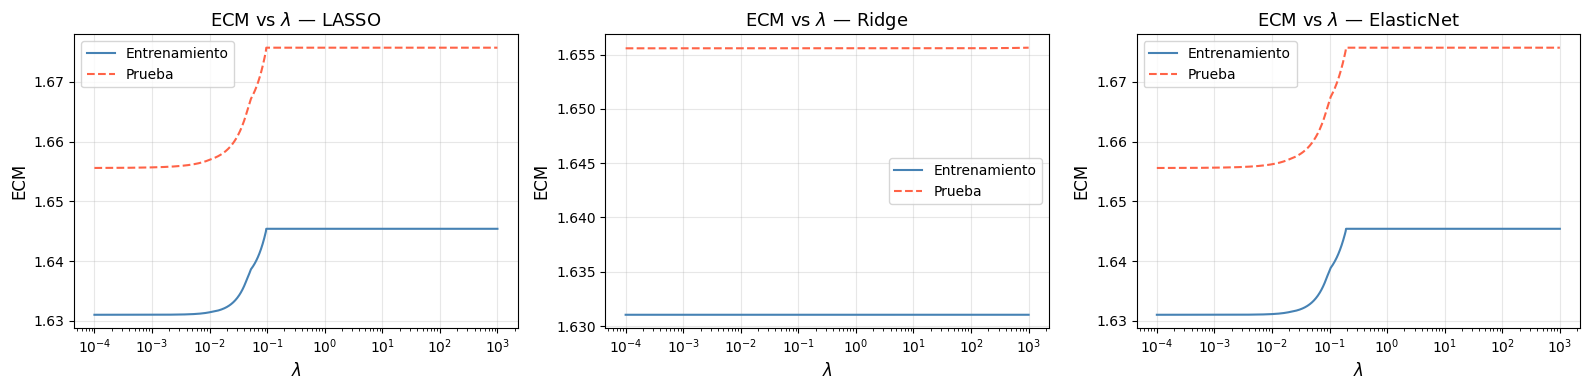

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, ecm_train, ecm_test, titulo in zip(
    axes,
    [ecm_train_lasso2, ecm_train_ridge2, ecm_train_EN],
    [ecm_test_lasso2, ecm_test_ridge2, ecm_test_EN],
    ["LASSO", "Ridge", "ElasticNet"],
    strict=False,
):
    ax.plot(lambdas, ecm_train, label="Entrenamiento", color="steelblue")
    ax.plot(lambdas, ecm_test, label="Prueba", color="tomato", linestyle="--")
    ax.set_xscale("log")
    ax.set_xlabel("$\\lambda$", fontsize=12)
    ax.set_ylabel("ECM", fontsize=12)
    ax.set_title(f"ECM vs $\\lambda$ — {titulo}", fontsize=13)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ecm_lambda2.png", dpi=150)
plt.show()

Se realiza el gráfico de las normas

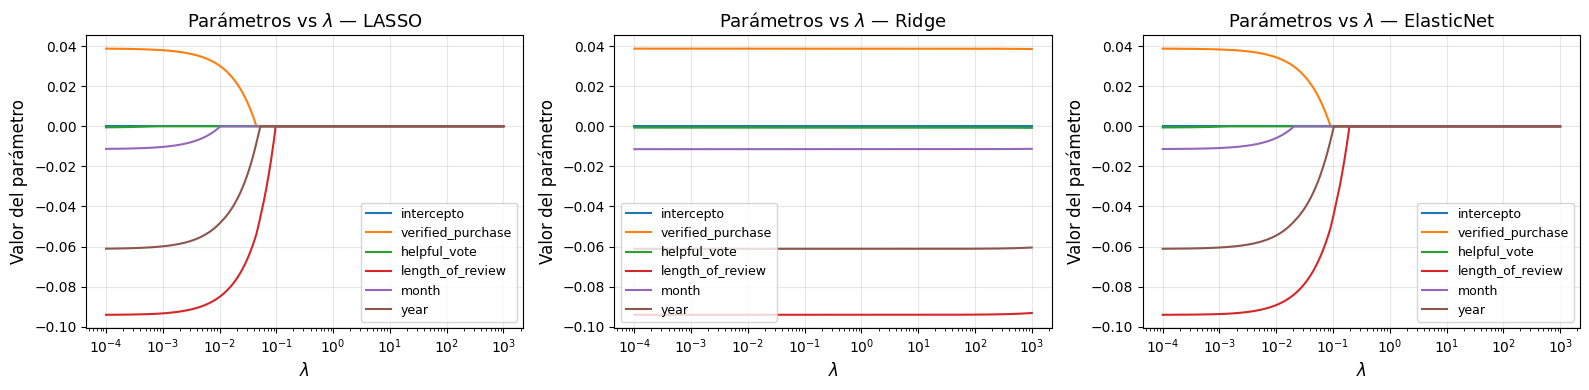

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
feat_names = ["verified_purchase", "helpful_vote", "length_of_review", "month", "year"]

for ax, thetas, titulo in zip(axes, [thetas_lasso2, thetas_ridge2, thetas_EN], ["LASSO", "Ridge", "ElasticNet"], strict=False):
    thetas_arr = np.array(thetas)
    for i, name in enumerate(feature_names):
        ax.plot(lambdas, thetas_arr[:, i], label=name)
    ax.set_xscale("log")
    ax.set_xlabel("$\\lambda$", fontsize=12)
    ax.set_ylabel("Valor del parámetro", fontsize=12)
    ax.set_title(f"Parámetros vs $\\lambda$ — {titulo}", fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("norma_parametros_scaled.png", dpi=150)
plt.show()

Se comparan las metricas

In [45]:
# Métricas MCO
ecm_tr2, rmse_tr2, mae_tr2, r2_tr2 = metricas(y_train2, y_pred_tr2)
ecm_te2, rmse_te2, mae_te2, r2_te2 = metricas(y_test2, y_pred_te2)

# Métricas para lasso, ridge y elasticnet
res_lasso = metricas_promedio(ecm_train_lasso2, ecm_test_lasso2, thetas_lasso2, X_train2, X_test2, y_train2, y_test2, Lasso, lambdas)

res_ridge = metricas_promedio(ecm_train_ridge2, ecm_test_ridge2, thetas_ridge2, X_train2, X_test2, y_train2, y_test2, Ridge, lambdas)

res_en = metricas_promedio(ecm_train_EN, ecm_test_EN, thetas_EN, X_train2, X_test2, y_train2, y_test2, ElasticNet, lambdas, l1_ratio=0.5)

# Tabla comparativa
header = f"{'Modelo':<12} {'ECM Tr':>8} {'ECM Te':>8} {'RMSE Tr':>9} {'RMSE Te':>9} {'MAE Tr':>8} {'MAE Te':>8} {'R2 Tr':>7} {'R2 Te':>7}"
print(header)
print("-" * len(header))

# MCO
print(f"{'MCO':<12} {ecm_tr2:>8.4f} {ecm_te2:>8.4f} {rmse_tr2:>9.4f} {rmse_te2:>9.4f} {mae_tr2:>8.4f} {mae_te2:>8.4f} {r2_tr2:>7.4f} {r2_te2:>7.4f}")

# Regularizados
for nombre, res in [("LASSO*", res_lasso), ("Ridge*", res_ridge), ("ElasticNet*", res_en)]:
    print(f"{nombre:<12} {res['ECM Tr']:>8.4f} {res['ECM Te']:>8.4f} {res['RMSE Tr']:>9.4f} {res['RMSE Te']:>9.4f} {res['MAE Tr']:>8.4f} {res['MAE Te']:>8.4f} {res['R2 Tr']:>7.4f} {res['R2 Te']:>7.4f}")

Modelo         ECM Tr   ECM Te   RMSE Tr   RMSE Te   MAE Tr   MAE Te   R2 Tr   R2 Te
------------------------------------------------------------------------------------
MCO            1.6310   1.6556    1.2771    1.2867   0.9952   1.0014  0.0087  0.0119
LASSO*         1.6399   1.6682    1.2806    1.2916   1.0004   1.0081  0.0033  0.0044
Ridge*         1.6310   1.6556    1.2771    1.2867   0.9952   1.0015  0.0087  0.0119
ElasticNet*    1.6393   1.6674    1.2804    1.2913   1.0000   1.0077  0.0037  0.0049


i) Analisís de Normalidad y Homocedasticidad

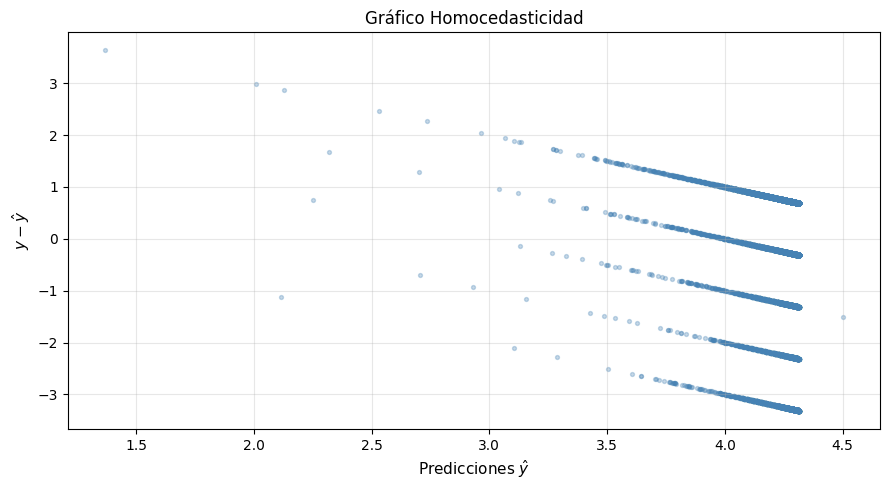

In [46]:
residuos = y_test - y_pred_test
fig, ax = plt.subplots(figsize=(9, 5))

# Scatter de predicciones vs residuos
ax.scatter(y_pred_test, residuos, alpha=0.3, s=8, color="steelblue")

ax.set_xlabel("Predicciones $\\hat{y}$", fontsize=11)
ax.set_ylabel("$y - \\hat{y}$", fontsize=11)
ax.set_title(r"Gráfico Homocedasticidad", fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("homocedasticidad.png", dpi=150)
plt.show()

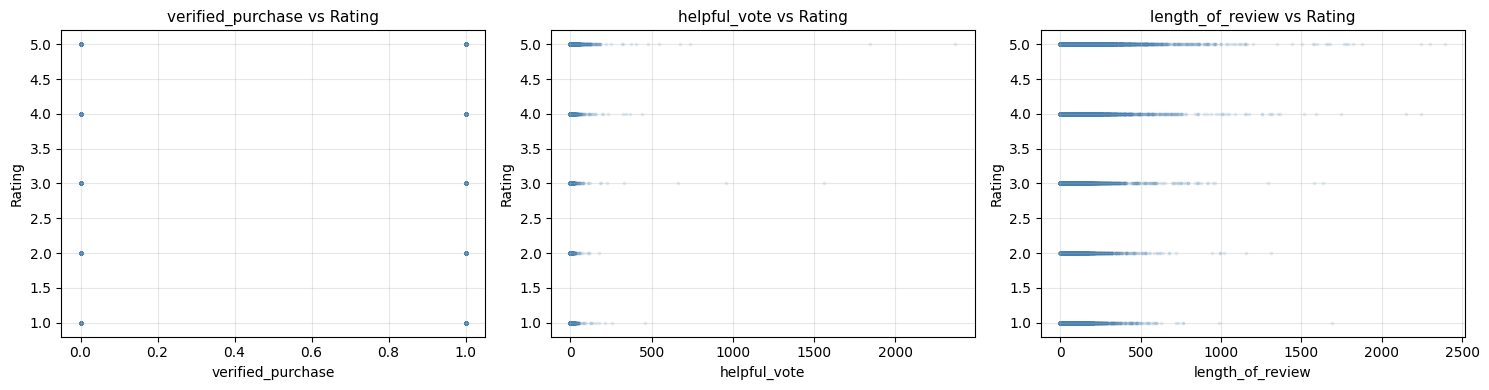

In [ ]:
# Dispersión variables predictoras vs rating (Linealidad)
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
feature_names = ["verified_purchase", "helpful_vote", "length_of_review"]

for _i, (ax, name) in enumerate(zip(axes2, feature_names, strict=False)):
    ax.scatter(df[name], df["rating"], alpha=0.1, s=3, color="steelblue")
    # Línea de tendencia
    # z = np.polyfit(df[name], df['rating'], 1)
    # p = np.poly1d(z)
    # x_line = np.linspace(df[name].min(), df[name].max(), 100)
    # ax.plot(x_line, p(x_line), color='red', linewidth=1.5, linestyle='--', label='Tendencia lineal')
    ax.set_xlabel(name, fontsize=10)
    ax.set_ylabel("Rating", fontsize=10)
    ax.set_title(f"{name} vs Rating", fontsize=11)
    # ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("dispersion_variables.png", dpi=150)
plt.show()

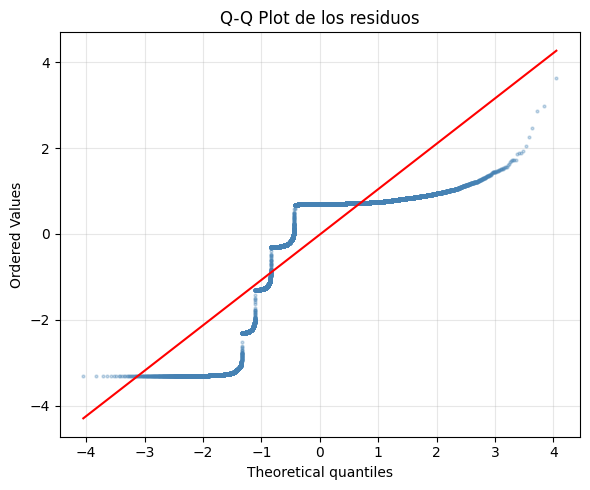

In [48]:
# Q-Q Plot (Normalidad de errores)
fig3, ax3 = plt.subplots(figsize=(6, 5))
stats.probplot(residuos, dist="norm", plot=ax3)
ax3.set_title("Q-Q Plot de los residuos", fontsize=12)
ax3.get_lines()[0].set(markersize=2, alpha=0.3, color="steelblue")
ax3.get_lines()[1].set(color="red", linewidth=1.5)
ax3.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("qqplot.png", dpi=150)
plt.show()

In [49]:
# Estadísticas descriptivas de los residuos
print(f"Media de residuos  : {residuos.mean():.4f}")
print(f"Std de residuos    : {residuos.std():.4f}")
print(f"Mín de residuos    : {residuos.min():.4f}")
print(f"Máx de residuos    : {residuos.max():.4f}")

Media de residuos  : -0.0123
Std de residuos    : 1.2889
Mín de residuos    : -3.3163
Máx de residuos    : 3.6337
